In [6]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

import numpy as np
from tslearn.clustering import TimeSeriesKMeans
from tslearn.datasets import CachedDatasets
from tslearn.preprocessing import TimeSeriesScalerMeanVariance, \
    TimeSeriesResampler
import seaborn as sns
from tslearn.utils import to_time_series_dataset
from tslearn.clustering import silhouette_score

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score 
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import sklearn.cluster

import os
from yellowbrick.cluster import SilhouetteVisualizer

import math
import scipy

from sklearn.metrics import adjusted_rand_score
from tslearn.metrics import soft_dtw

## Visualization Function

In [7]:
def ts_cluster_visualization(y_pred, df, n_clusters, plot_title):
    ts_size = df.shape[1]
    ts_max = df.max()
    plt.figure()
    for cluster in range(n_clusters):
        plt.subplot(4, math.ceil(n_clusters/4), cluster+1)
        for ts in df[y_pred == cluster]:
            plt.plot(ts.ravel(), "k-", alpha=.2)
        plt.plot(np.mean(df[y_pred == cluster], axis=0), "r-")
        plt.xlim(0, ts_size)
        plt.ylim(0, ts_max)
        plt.text(0.55, 0.35,'Cluster %d' % (cluster),
                 transform=plt.gca().transAxes)
        if cluster == 1:
            plt.title(plot_title)      
    plt.tight_layout()
    plt.show()

## Distance Function

In [8]:
def ts_cluster_distance(y_pred, df, n_clusters, distance_measure, gamma=1.0):
    distances = list()
    for cluster in range(n_clusters):
        cluster_center = np.mean(df[y_pred == cluster], axis=0)
        for ts in df[y_pred == cluster]:
            if(distance_measure == "Euclidean"):
                diff = np.sqrt(np.sum((ts.ravel() - cluster_center)**2))
            elif distance_measure == "SoftDTW":
                diff = soft_dtw(ts.reshape(-1, 1), cluster_center.reshape(-1, 1), gamma=gamma)
            else:
                raise ValueError("Unsupported distance measure: choose 'Euclidean' or 'SoftDTW'")
            distances.append(diff)
    return np.mean(distances)

## Bank Reserves

In [9]:
label_results = pd.read_csv('bank_reserves_results.csv', index_col=0)
br_poor = pd.read_csv("SimData/bank_reserves_outputs_poor.csv", header=None)
br_poor_ts = to_time_series_dataset(br_poor)

In [10]:
distance_br_pca_kmeans = ts_cluster_distance(label_results.loc["PCA_KMeans"].to_numpy(), br_poor_ts, 7, "SoftDTW")
distance_br_pca_agglom = ts_cluster_distance(label_results.loc["PCA_Agglom"].to_numpy(), br_poor_ts, 7, "SoftDTW")
distance_br_pca_spectral = ts_cluster_distance(label_results.loc["PCA_Spectral"].to_numpy(), br_poor_ts, 7, "SoftDTW")

distance_br_dae_kmeans = ts_cluster_distance(label_results.loc["DAE_KMeans"].to_numpy(), br_poor_ts, 7, "SoftDTW")
distance_br_dae_agglom = ts_cluster_distance(label_results.loc["DAE_Agglom"].to_numpy(), br_poor_ts, 7, "SoftDTW")
distance_br_dae_spectral = ts_cluster_distance(label_results.loc["DAE_Spectral"].to_numpy(), br_poor_ts, 7, "SoftDTW")

distance_br_dcae_kmeans = ts_cluster_distance(label_results.loc["DCAE_KMeans"].to_numpy(), br_poor_ts, 7, "SoftDTW")
distance_br_dcae_agglom = ts_cluster_distance(label_results.loc["DCAE_Agglom"].to_numpy(), br_poor_ts, 7, "SoftDTW")
distance_br_dcae_spectral = ts_cluster_distance(label_results.loc["DCAE_Spectral"].to_numpy(), br_poor_ts, 7, "SoftDTW")

In [11]:
br_results_poor_df = pd.DataFrame({
    "Feature": ["PCA", "PCA", "PCA", "DAE", "DAE", "DAE", "DCAE", "DCAE", "DCAE"],
    "Cluster": ["KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral"],
    "Value": [distance_br_pca_kmeans, distance_br_pca_agglom, distance_br_pca_spectral, 
              distance_br_dae_kmeans, distance_br_dae_agglom, distance_br_dae_spectral,
              distance_br_dcae_kmeans, distance_br_dcae_agglom, distance_br_dcae_spectral]
})

In [12]:
br_poor = pd.read_csv("SimData/bank_reserves_outputs_middle.csv", header=None)
br_poor_ts = to_time_series_dataset(br_poor)

In [13]:
distance_br_pca_kmeans = ts_cluster_distance(label_results.loc["PCA_KMeans"].to_numpy(), br_poor_ts, 7, "SoftDTW")
distance_br_pca_agglom = ts_cluster_distance(label_results.loc["PCA_Agglom"].to_numpy(), br_poor_ts, 7, "SoftDTW")
distance_br_pca_spectral = ts_cluster_distance(label_results.loc["PCA_Spectral"].to_numpy(), br_poor_ts, 7, "SoftDTW")

distance_br_dae_kmeans = ts_cluster_distance(label_results.loc["DAE_KMeans"].to_numpy(), br_poor_ts, 7, "SoftDTW")
distance_br_dae_agglom = ts_cluster_distance(label_results.loc["DAE_Agglom"].to_numpy(), br_poor_ts, 7, "SoftDTW")
distance_br_dae_spectral = ts_cluster_distance(label_results.loc["DAE_Spectral"].to_numpy(), br_poor_ts, 7, "SoftDTW")

distance_br_dcae_kmeans = ts_cluster_distance(label_results.loc["DCAE_KMeans"].to_numpy(), br_poor_ts, 7, "SoftDTW")
distance_br_dcae_agglom = ts_cluster_distance(label_results.loc["DCAE_Agglom"].to_numpy(), br_poor_ts, 7, "SoftDTW")
distance_br_dcae_spectral = ts_cluster_distance(label_results.loc["DCAE_Spectral"].to_numpy(), br_poor_ts, 7, "SoftDTW")

In [14]:
br_results_middle_df = pd.DataFrame({
    "Feature": ["PCA", "PCA", "PCA", "DAE", "DAE", "DAE", "DCAE", "DCAE", "DCAE"],
    "Cluster": ["KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral"],
    "Value": [distance_br_pca_kmeans, distance_br_pca_agglom, distance_br_pca_spectral, 
              distance_br_dae_kmeans, distance_br_dae_agglom, distance_br_dae_spectral,
              distance_br_dcae_kmeans, distance_br_dcae_agglom, distance_br_dcae_spectral]
})

In [15]:
br_results_middle_df

,Feature,Cluster,Value
0,PCA,KMeans,27771.112037
1,PCA,Agglomerative,20991.890338
2,PCA,Spectral,10796.564760
3,DAE,KMeans,7267.740635
4,DAE,Agglomerative,7494.642432
5,DAE,Spectral,11698.471016
6,DCAE,KMeans,7651.971752
7,DCAE,Agglomerative,15241.775267
8,DCAE,Spectral,9975.868051


In [16]:
br_poor = pd.read_csv("SimData/bank_reserves_outputs_rich.csv", header=None)
br_poor_ts = to_time_series_dataset(br_poor)

In [17]:
distance_br_pca_kmeans = ts_cluster_distance(label_results.loc["PCA_KMeans"].to_numpy(), br_poor_ts, 7, "SoftDTW")
distance_br_pca_agglom = ts_cluster_distance(label_results.loc["PCA_Agglom"].to_numpy(), br_poor_ts, 7, "SoftDTW")
distance_br_pca_spectral = ts_cluster_distance(label_results.loc["PCA_Spectral"].to_numpy(), br_poor_ts, 7, "SoftDTW")

distance_br_dae_kmeans = ts_cluster_distance(label_results.loc["DAE_KMeans"].to_numpy(), br_poor_ts, 7, "SoftDTW")
distance_br_dae_agglom = ts_cluster_distance(label_results.loc["DAE_Agglom"].to_numpy(), br_poor_ts, 7, "SoftDTW")
distance_br_dae_spectral = ts_cluster_distance(label_results.loc["DAE_Spectral"].to_numpy(), br_poor_ts, 7, "SoftDTW")

distance_br_dcae_kmeans = ts_cluster_distance(label_results.loc["DCAE_KMeans"].to_numpy(), br_poor_ts, 7, "SoftDTW")
distance_br_dcae_agglom = ts_cluster_distance(label_results.loc["DCAE_Agglom"].to_numpy(), br_poor_ts, 7, "SoftDTW")
distance_br_dcae_spectral = ts_cluster_distance(label_results.loc["DCAE_Spectral"].to_numpy(), br_poor_ts, 7, "SoftDTW")

In [18]:
br_results_rich_df = pd.DataFrame({
    "Feature": ["PCA", "PCA", "PCA", "DAE", "DAE", "DAE", "DCAE", "DCAE", "DCAE"],
    "Cluster": ["KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral"],
    "Value": [distance_br_pca_kmeans, distance_br_pca_agglom, distance_br_pca_spectral, 
              distance_br_dae_kmeans, distance_br_dae_agglom, distance_br_dae_spectral,
              distance_br_dcae_kmeans, distance_br_dcae_agglom, distance_br_dcae_spectral]
})

In [19]:
br_results_rich_df

,Feature,Cluster,Value
0,PCA,KMeans,3980.790048
1,PCA,Agglomerative,3344.702558
2,PCA,Spectral,2523.873535
3,DAE,KMeans,2351.379015
4,DAE,Agglomerative,2330.786791
5,DAE,Spectral,2753.221577
6,DCAE,KMeans,2422.375441
7,DCAE,Agglomerative,3021.138106
8,DCAE,Spectral,2646.137539


In [20]:
br_results_poor_df['Value'] = br_results_poor_df['Value'].apply(lambda x: x/2494.697987853243)
br_results_middle_df['Value'] = br_results_middle_df['Value'].apply(lambda x: x/7168.584332725069)
br_results_rich_df['Value'] = br_results_rich_df['Value'].apply(lambda x: x/2511.7120814591794)

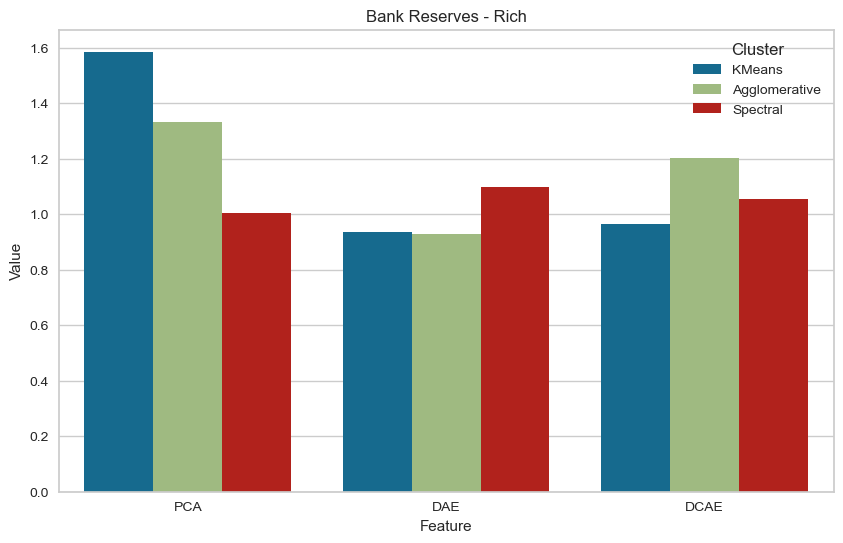

In [21]:
plt.figure(figsize=(10, 6))
sns.barplot(data=br_results_rich_df, x="Feature", y="Value", hue="Cluster")

# Customize the plot
plt.xlabel("Feature")
plt.ylabel("Value")
plt.title("Bank Reserves - Rich")
plt.legend(title="Cluster")
#plt.ylim(3800, 4300)
plt.savefig("bank_reserves_rich_overall_norm.png", format="png")
plt.show()

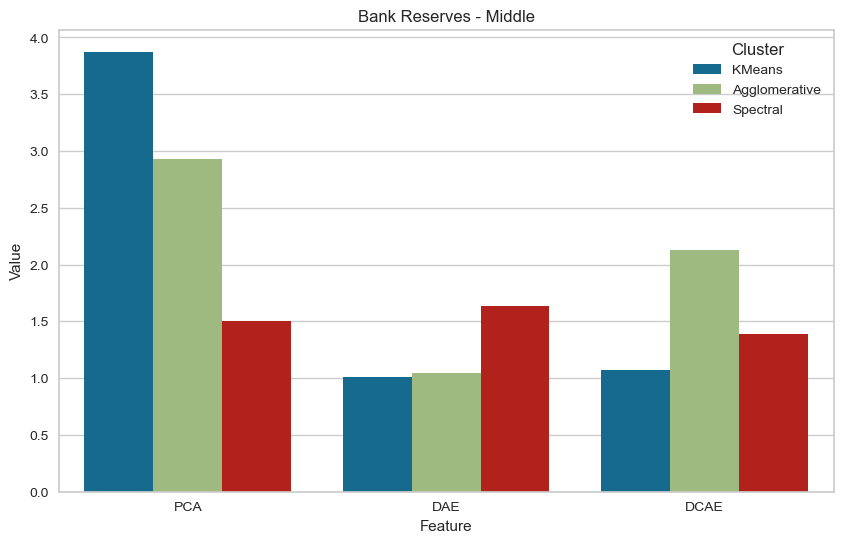

In [22]:
plt.figure(figsize=(10, 6))
sns.barplot(data=br_results_middle_df, x="Feature", y="Value", hue="Cluster")

# Customize the plot
plt.xlabel("Feature")
plt.ylabel("Value")
plt.title("Bank Reserves - Middle")
plt.legend(title="Cluster")
#plt.ylim(7200, 7900)
plt.savefig("bank_reserves_middle_overall_norm.png", format="png")
plt.show()

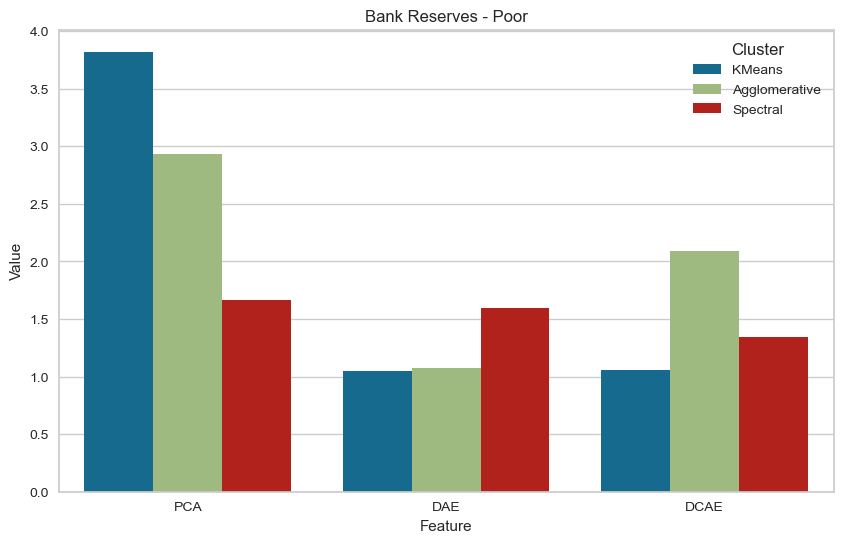

In [23]:
plt.figure(figsize=(10, 6))
sns.barplot(data=br_results_poor_df, x="Feature", y="Value", hue="Cluster")

# Customize the plot
plt.xlabel("Feature")
plt.ylabel("Value")
plt.title("Bank Reserves - Poor")
plt.legend(title="Cluster")
#plt.ylim(3800, 4300)
plt.savefig("bank_reserves_poor_overall_norm.png", format="png")
plt.show()

# Epstein

In [24]:
label_results = pd.read_csv('epstein_results.csv', index_col=0)
ecv_active = pd.read_csv("SimData/epsteinCV_outputs_active.csv", header=None)
ecv_active_ts = to_time_series_dataset(ecv_active)

In [25]:
distance_ecv_pca_kmeans = ts_cluster_distance(label_results.loc["PCA_KMeans"].to_numpy(), ecv_active_ts, 8, "SoftDTW")
distance_ecv_pca_agglom = ts_cluster_distance(label_results.loc["PCA_Agglom"].to_numpy(), ecv_active_ts, 8, "SoftDTW")
distance_ecv_pca_spectral = ts_cluster_distance(label_results.loc["PCA_Spectral"].to_numpy(), ecv_active_ts, 8, "SoftDTW")

distance_ecv_dae_kmeans = ts_cluster_distance(label_results.loc["DAE_KMeans"].to_numpy(), ecv_active_ts, 8, "SoftDTW")
distance_ecv_dae_agglom = ts_cluster_distance(label_results.loc["DAE_Agglom"].to_numpy(), ecv_active_ts, 8, "SoftDTW")
distance_ecv_dae_spectral = ts_cluster_distance(label_results.loc["DAE_Spectral"].to_numpy(), ecv_active_ts, 8, "SoftDTW")

distance_ecv_dcae_kmeans = ts_cluster_distance(label_results.loc["DCAE_KMeans"].to_numpy(), ecv_active_ts, 8, "SoftDTW")
distance_ecv_dcae_agglom = ts_cluster_distance(label_results.loc["DCAE_Agglom"].to_numpy(), ecv_active_ts, 8, "SoftDTW")
distance_ecv_dcae_spectral = ts_cluster_distance(label_results.loc["DCAE_Spectral"].to_numpy(), ecv_active_ts, 8, "SoftDTW")

In [26]:
ecv_results_active_df = pd.DataFrame({
    "Feature": ["PCA", "PCA", "PCA", "DAE", "DAE", "DAE", "DCAE", "DCAE", "DCAE"],
    "Cluster": ["KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral"],
    "Value": [distance_ecv_pca_kmeans, distance_ecv_pca_agglom, distance_ecv_pca_spectral, 
              distance_ecv_dae_kmeans, distance_ecv_dae_agglom, distance_ecv_dae_spectral,
              distance_ecv_dcae_kmeans, distance_ecv_dcae_agglom, distance_ecv_dcae_spectral]
})

In [27]:
ecv_jailed = pd.read_csv("SimData/epsteinCV_outputs_jailed.csv", header=None)
ecv_jailed_ts = to_time_series_dataset(ecv_jailed)

In [28]:
distance_ecv_pca_kmeans = ts_cluster_distance(label_results.loc["PCA_KMeans"].to_numpy(), ecv_jailed_ts, 8, "SoftDTW")
distance_ecv_pca_agglom = ts_cluster_distance(label_results.loc["PCA_Agglom"].to_numpy(), ecv_jailed_ts, 8, "SoftDTW")
distance_ecv_pca_spectral = ts_cluster_distance(label_results.loc["PCA_Spectral"].to_numpy(), ecv_jailed_ts, 8, "SoftDTW")

distance_ecv_dae_kmeans = ts_cluster_distance(label_results.loc["DAE_KMeans"].to_numpy(), ecv_jailed_ts, 8, "SoftDTW")
distance_ecv_dae_agglom = ts_cluster_distance(label_results.loc["DAE_Agglom"].to_numpy(), ecv_jailed_ts, 8, "SoftDTW")
distance_ecv_dae_spectral = ts_cluster_distance(label_results.loc["DAE_Spectral"].to_numpy(), ecv_jailed_ts, 8, "SoftDTW")

distance_ecv_dcae_kmeans = ts_cluster_distance(label_results.loc["DCAE_KMeans"].to_numpy(), ecv_jailed_ts, 8, "SoftDTW")
distance_ecv_dcae_agglom = ts_cluster_distance(label_results.loc["DCAE_Agglom"].to_numpy(), ecv_jailed_ts, 8, "SoftDTW")
distance_ecv_dcae_spectral = ts_cluster_distance(label_results.loc["DCAE_Spectral"].to_numpy(), ecv_jailed_ts, 8, "SoftDTW")

In [29]:
ecv_results_jailed_df = pd.DataFrame({
    "Feature": ["PCA", "PCA", "PCA", "DAE", "DAE", "DAE", "DCAE", "DCAE", "DCAE"],
    "Cluster": ["KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral"],
    "Value": [distance_ecv_pca_kmeans, distance_ecv_pca_agglom, distance_ecv_pca_spectral, 
              distance_ecv_dae_kmeans, distance_ecv_dae_agglom, distance_ecv_dae_spectral,
              distance_ecv_dcae_kmeans, distance_ecv_dcae_agglom, distance_ecv_dcae_spectral]
})

In [30]:
ecv_quiet = pd.read_csv("SimData/epsteinCV_outputs_quiet.csv", header=None)
ecv_quiet_ts = to_time_series_dataset(ecv_quiet)

In [31]:
distance_ecv_pca_kmeans = ts_cluster_distance(label_results.loc["PCA_KMeans"].to_numpy(), ecv_quiet_ts, 8, "SoftDTW")
distance_ecv_pca_agglom = ts_cluster_distance(label_results.loc["PCA_Agglom"].to_numpy(), ecv_quiet_ts, 8, "SoftDTW")
distance_ecv_pca_spectral = ts_cluster_distance(label_results.loc["PCA_Spectral"].to_numpy(), ecv_quiet_ts, 8, "SoftDTW")

distance_ecv_dae_kmeans = ts_cluster_distance(label_results.loc["DAE_KMeans"].to_numpy(), ecv_quiet_ts, 8, "SoftDTW")
distance_ecv_dae_agglom = ts_cluster_distance(label_results.loc["DAE_Agglom"].to_numpy(), ecv_quiet_ts, 8, "SoftDTW")
distance_ecv_dae_spectral = ts_cluster_distance(label_results.loc["DAE_Spectral"].to_numpy(), ecv_quiet_ts, 8, "SoftDTW")

distance_ecv_dcae_kmeans = ts_cluster_distance(label_results.loc["DCAE_KMeans"].to_numpy(), ecv_quiet_ts, 8, "SoftDTW")
distance_ecv_dcae_agglom = ts_cluster_distance(label_results.loc["DCAE_Agglom"].to_numpy(), ecv_quiet_ts, 8, "SoftDTW")
distance_ecv_dcae_spectral = ts_cluster_distance(label_results.loc["DCAE_Spectral"].to_numpy(), ecv_quiet_ts, 8, "SoftDTW")

In [32]:
ecv_results_quiet_df = pd.DataFrame({
    "Feature": ["PCA", "PCA", "PCA", "DAE", "DAE", "DAE", "DCAE", "DCAE", "DCAE"],
    "Cluster": ["KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral"],
    "Value": [distance_ecv_pca_kmeans, distance_ecv_pca_agglom, distance_ecv_pca_spectral, 
              distance_ecv_dae_kmeans, distance_ecv_dae_agglom, distance_ecv_dae_spectral,
              distance_ecv_dcae_kmeans, distance_ecv_dcae_agglom, distance_ecv_dcae_spectral]
})

In [33]:
ecv_results_active_df['Value'] = ecv_results_active_df['Value'].apply(lambda x: x/1662447.0778391678)
ecv_results_jailed_df['Value'] = ecv_results_jailed_df['Value'].apply(lambda x: x/935593.2755125551)
ecv_results_quiet_df['Value'] = ecv_results_quiet_df['Value'].apply(lambda x: x/3051922.3458011313)

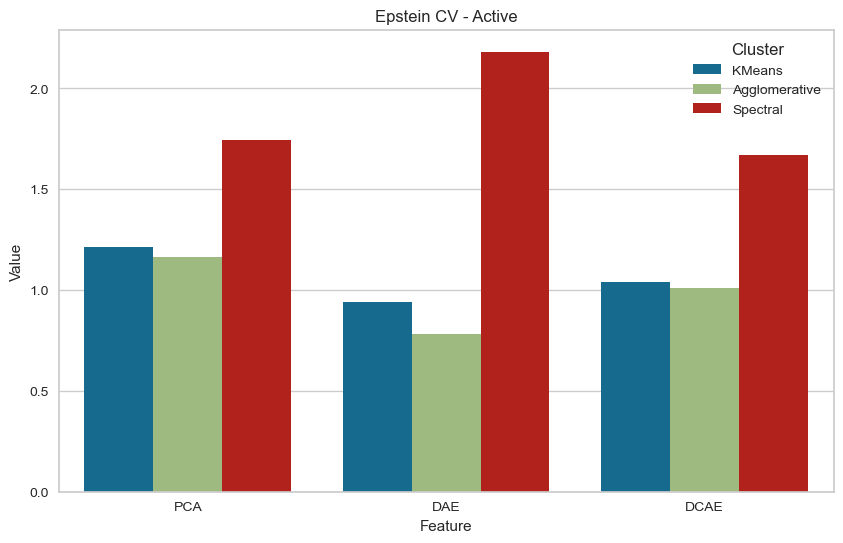

In [34]:
plt.figure(figsize=(10, 6))
sns.barplot(data=ecv_results_active_df, x="Feature", y="Value", hue="Cluster")

# Customize the plot
plt.xlabel("Feature")
plt.ylabel("Value")
plt.title("Epstein CV - Active")
plt.legend(title="Cluster")
#plt.ylim(10000, 20000)
plt.savefig("epstein_active_overall_norm.png", format="png")
plt.show()

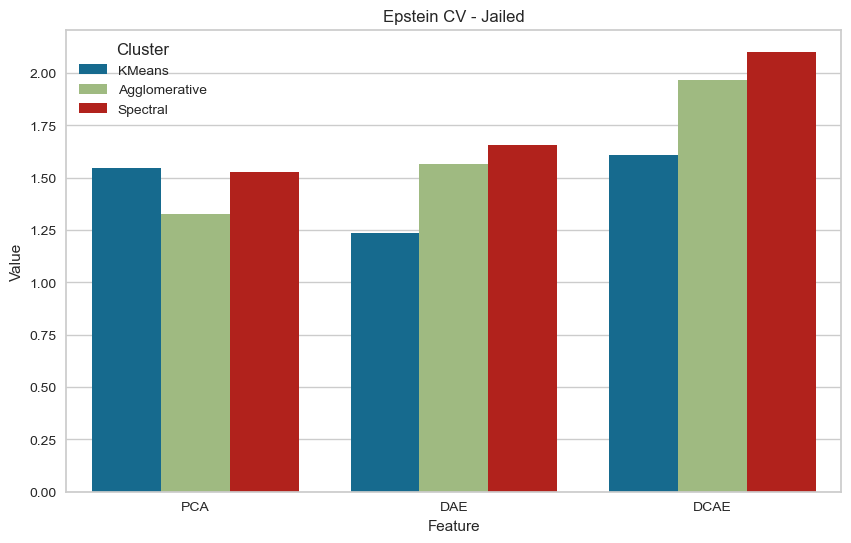

In [35]:
plt.figure(figsize=(10, 6))
sns.barplot(data=ecv_results_jailed_df, x="Feature", y="Value", hue="Cluster")

# Customize the plot
plt.xlabel("Feature")
plt.ylabel("Value")
plt.title("Epstein CV - Jailed")
plt.legend(title="Cluster")
#plt.ylim(10000, 25000)
plt.savefig("epstein_jailed_overall_norm.png", format="png")
plt.show()

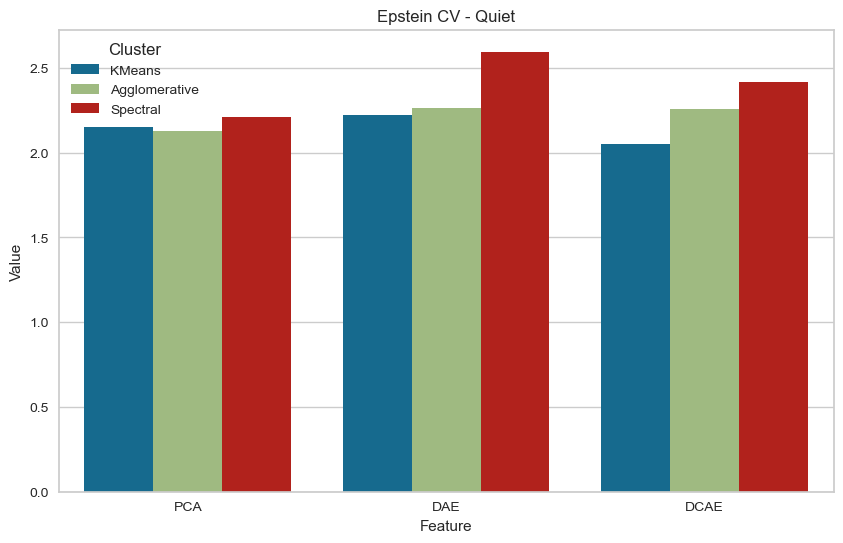

In [36]:
plt.figure(figsize=(10, 6))
sns.barplot(data=ecv_results_quiet_df, x="Feature", y="Value", hue="Cluster")

# Customize the plot
plt.xlabel("Feature")
plt.ylabel("Value")
plt.title("Epstein CV - Quiet")
plt.legend(title="Cluster")
#plt.ylim(15000, 45000)
plt.savefig("epstein_quiet_overall_norm.png", format="png")
plt.show()

In [37]:
def import_ff_data(filename):
    expected_columns=155
    data = []
    with open(filename, 'r') as file:
        for line in file:
            row = line.strip().split(',')
            if len(row) < expected_columns:
                row += [np.nan] * (expected_columns - len(row))
            data.append(row)
    df = pd.DataFrame(data)
    def fill_last_valid(row):
        for i in range(1, len(row)):
            if pd.isna(row[i]):
                row[i] = row[i - 1]  
        return row
    df_filled = df.apply(fill_last_valid, axis=1)
    return df_filled

In [38]:
label_results = pd.read_csv('forestfire_results.csv', index_col=0)
ff_onfire = import_ff_data("SimData/forest_fire_outputs_onfire.csv")
ff_onfire_ts = to_time_series_dataset(ff_onfire)

In [ ]:
distance_ff_pca_kmeans = ts_cluster_distance(label_results.loc["PCA_KMeans"].to_numpy(), ff_onfire_ts, 4, "SoftDTW")
distance_ff_pca_agglom = ts_cluster_distance(label_results.loc["PCA_Agglom"].to_numpy(), ff_onfire_ts, 4, "SoftDTW")
distance_ff_pca_spectral = ts_cluster_distance(label_results.loc["PCA_Spectral"].to_numpy(), ff_onfire_ts, 4, "SoftDTW")

distance_ff_dae_kmeans = ts_cluster_distance(label_results.loc["DAE_KMeans"].to_numpy(), ff_onfire_ts, 4, "SoftDTW")
distance_ff_dae_agglom = ts_cluster_distance(label_results.loc["DAE_Agglom"].to_numpy(), ff_onfire_ts, 4, "SoftDTW")
distance_ff_dae_spectral = ts_cluster_distance(label_results.loc["DAE_Spectral"].to_numpy(), ff_onfire_ts, 4, "SoftDTW")

distance_ff_dcae_kmeans = ts_cluster_distance(label_results.loc["DCAE_KMeans"].to_numpy(), ff_onfire_ts, 4, "SoftDTW")
distance_ff_dcae_agglom = ts_cluster_distance(label_results.loc["DCAE_Agglom"].to_numpy(), ff_onfire_ts, 4, "SoftDTW")
distance_ff_dcae_spectral = ts_cluster_distance(label_results.loc["DCAE_Spectral"].to_numpy(), ff_onfire_ts, 4, "SoftDTW")

In [ ]:
ff_results_onfire_df = pd.DataFrame({
    "Feature": ["PCA", "PCA", "PCA", "DAE", "DAE", "DAE", "DCAE", "DCAE", "DCAE"],
    "Cluster": ["KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral"],
    "Value": [distance_ff_pca_kmeans, distance_ff_pca_agglom, distance_ff_pca_spectral, 
              distance_ff_dae_kmeans, distance_ff_dae_agglom, distance_ff_dae_spectral,
              distance_ff_dcae_kmeans, distance_ff_dcae_agglom, distance_ff_dcae_spectral]
})

In [ ]:
ff_fine = import_ff_data("SimData/forest_fire_outputs_fine.csv")
ff_fine_ts = to_time_series_dataset(ff_fine)

In [ ]:
distance_ff_pca_kmeans = ts_cluster_distance(label_results.loc["PCA_KMeans"].to_numpy(), ff_fine_ts, 4, "SoftDTW")
distance_ff_pca_agglom = ts_cluster_distance(label_results.loc["PCA_Agglom"].to_numpy(), ff_fine_ts, 4, "SoftDTW")
distance_ff_pca_spectral = ts_cluster_distance(label_results.loc["PCA_Spectral"].to_numpy(), ff_fine_ts, 4, "SoftDTW")

distance_ff_dae_kmeans = ts_cluster_distance(label_results.loc["DAE_KMeans"].to_numpy(), ff_fine_ts, 4, "SoftDTW")
distance_ff_dae_agglom = ts_cluster_distance(label_results.loc["DAE_Agglom"].to_numpy(), ff_fine_ts, 4, "SoftDTW")
distance_ff_dae_spectral = ts_cluster_distance(label_results.loc["DAE_Spectral"].to_numpy(), ff_fine_ts, 4, "SoftDTW")

distance_ff_dcae_kmeans = ts_cluster_distance(label_results.loc["DCAE_KMeans"].to_numpy(), ff_fine_ts, 4, "SoftDTW")
distance_ff_dcae_agglom = ts_cluster_distance(label_results.loc["DCAE_Agglom"].to_numpy(), ff_fine_ts, 4, "SoftDTW")
distance_ff_dcae_spectral = ts_cluster_distance(label_results.loc["DCAE_Spectral"].to_numpy(), ff_fine_ts, 4, "SoftDTW")

In [ ]:
ff_results_fine_df = pd.DataFrame({
    "Feature": ["PCA", "PCA", "PCA", "DAE", "DAE", "DAE", "DCAE", "DCAE", "DCAE"],
    "Cluster": ["KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral"],
    "Value": [distance_ff_pca_kmeans, distance_ff_pca_agglom, distance_ff_pca_spectral, 
              distance_ff_dae_kmeans, distance_ff_dae_agglom, distance_ff_dae_spectral,
              distance_ff_dcae_kmeans, distance_ff_dcae_agglom, distance_ff_dcae_spectral]
})

In [ ]:
ff_burned = import_ff_data("SimData/forest_fire_outputs_burned.csv")
ff_burned_ts = to_time_series_dataset(ff_burned)

In [ ]:
distance_ff_pca_kmeans = ts_cluster_distance(label_results.loc["PCA_KMeans"].to_numpy(), ff_burned_ts, 4, "SoftDTW")
distance_ff_pca_agglom = ts_cluster_distance(label_results.loc["PCA_Agglom"].to_numpy(), ff_burned_ts, 4, "SoftDTW")
distance_ff_pca_spectral = ts_cluster_distance(label_results.loc["PCA_Spectral"].to_numpy(), ff_burned_ts, 4, "SoftDTW")

distance_ff_dae_kmeans = ts_cluster_distance(label_results.loc["DAE_KMeans"].to_numpy(), ff_burned_ts, 4, "SoftDTW")
distance_ff_dae_agglom = ts_cluster_distance(label_results.loc["DAE_Agglom"].to_numpy(), ff_burned_ts, 4, "SoftDTW")
distance_ff_dae_spectral = ts_cluster_distance(label_results.loc["DAE_Spectral"].to_numpy(), ff_burned_ts, 4, "SoftDTW")

distance_ff_dcae_kmeans = ts_cluster_distance(label_results.loc["DCAE_KMeans"].to_numpy(), ff_burned_ts, 4, "SoftDTW")
distance_ff_dcae_agglom = ts_cluster_distance(label_results.loc["DCAE_Agglom"].to_numpy(), ff_burned_ts, 4, "SoftDTW")
distance_ff_dcae_spectral = ts_cluster_distance(label_results.loc["DCAE_Spectral"].to_numpy(), ff_burned_ts, 4, "SoftDTW")

In [ ]:
ff_results_burned_df = pd.DataFrame({
    "Feature": ["PCA", "PCA", "PCA", "DAE", "DAE", "DAE", "DCAE", "DCAE", "DCAE"],
    "Cluster": ["KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral"],
    "Value": [distance_ff_pca_kmeans, distance_ff_pca_agglom, distance_ff_pca_spectral, 
              distance_ff_dae_kmeans, distance_ff_dae_agglom, distance_ff_dae_spectral,
              distance_ff_dcae_kmeans, distance_ff_dcae_agglom, distance_ff_dcae_spectral]
})

In [ ]:
ff_results_onfire_df['Value'] = ff_results_onfire_df['Value'].apply(lambda x: x/17640.456365358114)
ff_results_fine_df['Value'] = ff_results_fine_df['Value'].apply(lambda x: x/18933952.852686398)
ff_results_burned_df['Value'] = ff_results_burned_df['Value'].apply(lambda x: x/80475845.29474212)

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=ff_results_onfire_df, x="Feature", y="Value", hue="Cluster")

# Customize the plot
plt.xlabel("Feature")
plt.ylabel("Value")
plt.title("Forest Fire - On Fire")
plt.legend(title="Cluster")
#plt.ylim(5000, 8000)
plt.savefig("ff_onfire_overall_norm.png", format="png")
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=ff_results_fine_df, x="Feature", y="Value", hue="Cluster")

# Customize the plot
plt.xlabel("Feature")
plt.ylabel("Value")
plt.title("Forest Fire - Fine")
plt.legend(title="Cluster")
#plt.ylim(200000, 290000)
plt.savefig("ff_fine_overall_norm.png", format="png")
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=ff_results_burned_df, x="Feature", y="Value", hue="Cluster")

# Customize the plot
plt.xlabel("Feature")
plt.ylabel("Value")
plt.title("Forest Fire - Burned")
plt.legend(title="Cluster")
#plt.ylim(200000, 350000)
plt.savefig("ff_burned_overall_norm.png", format="png")
plt.show()